# Laboratorio 5 - Clasificación de dificultad de puzzles de ajedrez

**Dataset:** Lichess Puzzle Database - Classification Subset.  
**Tabla:** `muestra_procesada`.  
**SQLite:** `../database/proyecto_analitica.db`.

En esta primera parte se analiza: distribución de clases, desbalanceo, variables numéricas, variables categóricas/textuales y valores faltantes.

## 1. Definición de la variable objetivo

La variable objetivo `nivel_dificultad` se construye desde `Rating`:

| Clase | Nivel | Regla |
|---:|---|---|
| 0 | Principiante | `Rating < 1200` |
| 1 | Intermedio | `1200 <= Rating < 1800` |
| 2 | Avanzado | `1800 <= Rating < 2400` |
| 3 | Maestro | `Rating >= 2400` |

`Rating` **no debe usarse como predictor** porque sería fuga de información.

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', palette='viridis')

candidate_paths = [
    Path('../database/proyecto_analitica.db'),  # si el notebook se ejecuta desde notebooks/
    Path('database/proyecto_analitica.db')     # si el notebook se ejecuta desde la raíz del proyecto
]
DB_PATH = next((path for path in candidate_paths if path.exists()), None)
if DB_PATH is None:
    raise FileNotFoundError('No se encontro database/proyecto_analitica.db')

TABLE_NAME = 'muestra_procesada'

con = sqlite3.connect(DB_PATH)
schema = pd.read_sql_query(f'PRAGMA table_info({TABLE_NAME})', con)
total_registros = pd.read_sql_query(f'SELECT COUNT(*) AS total FROM {TABLE_NAME}', con).iloc[0, 0]

print(f'Base: {DB_PATH.resolve()}')
print(f'Total de registros: {total_registros:,}')
schema[['name', 'type']]

Base: C:\Users\user\Desktop\ml-project_analitica_datos\database\proyecto_analitica.db
Total de registros: 5,882,680


,name,type
0,PuzzleId,TEXT
1,FEN,TEXT
2,Moves,TEXT
3,Rating,INTEGER
4,RatingDeviation,INTEGER
5,Popularity,INTEGER
6,NbPlays,INTEGER
7,Themes,TEXT
8,GameUrl,TEXT
9,OpeningTags,TEXT


## 2. Distribución de clases

Se calcula directamente en SQL para evitar cargar toda la tabla en memoria.

In [2]:
query = f'''
SELECT
    CASE
        WHEN Rating < 1200 THEN 0
        WHEN Rating < 1800 THEN 1
        WHEN Rating < 2400 THEN 2
        ELSE 3
    END AS nivel_dificultad,
    CASE
        WHEN Rating < 1200 THEN 'Principiante'
        WHEN Rating < 1800 THEN 'Intermedio'
        WHEN Rating < 2400 THEN 'Avanzado'
        ELSE 'Maestro'
    END AS etiqueta_dificultad,
    COUNT(*) AS frecuencia
FROM {TABLE_NAME}
WHERE Rating IS NOT NULL
GROUP BY nivel_dificultad, etiqueta_dificultad
ORDER BY nivel_dificultad;
'''

distribución_clases = pd.read_sql_query(query, con)
distribución_clases['porcentaje'] = 100 * distribución_clases['frecuencia'] / distribución_clases['frecuencia'].sum()
distribución_clases

,nivel_dificultad,etiqueta_dificultad,frecuencia,porcentaje
0,0,Principiante,2127056,36.1579
1,1,Intermedio,2060929,35.0338
2,2,Avanzado,1356106,23.0525
3,3,Maestro,338589,5.7557


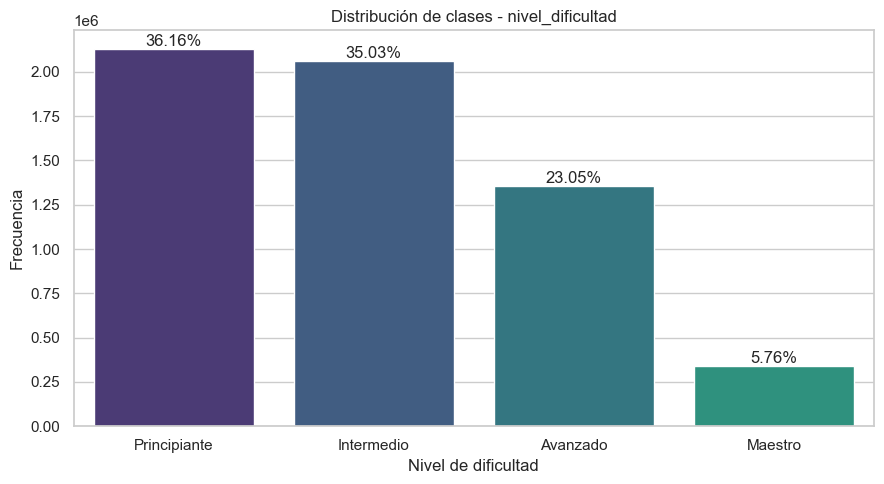

In [3]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=distribución_clases, x='etiqueta_dificultad', y='frecuencia', hue='etiqueta_dificultad', legend=False)
for i, row in distribución_clases.iterrows():
    ax.text(i, row['frecuencia'], f"{row['porcentaje']:.2f}%", ha='center', va='bottom')
plt.title('Distribución de clases - nivel_dificultad')
plt.xlabel('Nivel de dificultad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### Resultado inicial

En la tabla completa se observa esta distribución aproximada:

| Clase | Nivel | Frecuencia | Porcentaje |
|---:|---|---:|---:|
| 0 | Principiante | 2,127,056 | 36.16% |
| 1 | Intermedio | 2,060,929 | 35.03% |
| 2 | Avanzado | 1,356,106 | 23.05% |
| 3 | Maestro | 338,589 | 5.76% |

La clase `Maestro` es la minoritaria.

## 3. Desbalanceo de clases

In [4]:
mayoritaria = distribución_clases.loc[distribución_clases['frecuencia'].idxmax()]
minoritaria = distribución_clases.loc[distribución_clases['frecuencia'].idxmin()]

razon = mayoritaria['frecuencia'] / minoritaria['frecuencia']
dif_pp = mayoritaria['porcentaje'] - minoritaria['porcentaje']

pd.DataFrame({
    'indicador': ['Clase mayoritaria', 'Clase minoritaria', 'Razón mayoritaria/minoritaria', 'Diferencia porcentual'],
    'valor': [
        f"{mayoritaria['etiqueta_dificultad']} ({mayoritaria['porcentaje']:.2f}%)",
        f"{minoritaria['etiqueta_dificultad']} ({minoritaria['porcentaje']:.2f}%)",
        f"{razon:.2f}:1",
        f"{dif_pp:.2f} puntos porcentuales"
    ]
})

,indicador,valor
0,Clase mayoritaria,Principiante (36.16%)
1,Clase minoritaria,Maestro (5.76%)
2,Razón mayoritaria/minoritaria,6.28:1
3,Diferencia porcentual,30.40 puntos porcentuales


### Interpretación

Existe desbalanceo moderado-importante: la clase mayoritaria tiene alrededor de **6.28 veces** más observaciones que la clase minoritaria. Por eso, en las siguientes etapas se debe usar división estratificada, `StratifiedKFold` y métricas macro/ponderadas, no solo accuracy.

## 4. Variables numéricas

Se analizan las variables numéricas disponibles. `Rating` se reporta para entender la fuente del objetivo, pero no será predictor.

In [5]:
variables_numericas_predictoras = [
    'RatingDeviation', 'Popularity', 'NbPlays', 'branching_factor',
    'forcing_index', 'graph_density', 'tension_components',
    'spatial_entropy', 'com_chebyshev_dist'
]

expr = []
for col in ['Rating'] + variables_numericas_predictoras:
    expr += [f'MIN("{col}") AS "{col}_min"', f'AVG("{col}") AS "{col}_mean"', f'MAX("{col}") AS "{col}_max"']

stats = pd.read_sql_query(f"SELECT {', '.join(expr)} FROM {TABLE_NAME}", con).T.reset_index()
stats.columns = ['estadistico', 'valor']
stats[['variable', 'medida']] = stats['estadistico'].str.rsplit('_', n=1, expand=True)
stats.pivot(index='variable', columns='medida', values='valor').reset_index()[['variable', 'min', 'mean', 'max']]

medida,variable,min,mean,max
0,NbPlays,0.0000,"1,679.8393","312,634.0000"
1,Popularity,-83.0000,86.1315,100.0000
2,Rating,399.0000,"1,477.0740","3,329.0000"
3,RatingDeviation,45.0000,86.9521,500.0000
4,branching_factor,2.0000,30.5275,70.0000
5,com_chebyshev_dist,0.0000,3.0360,7.0000
6,forcing_index,0.0000,0.1302,1.0000
7,graph_density,0.0000,0.0742,0.6667
8,spatial_entropy,0.0000,1.2218,1.3863
9,tension_components,1.0000,2.7742,15.0000


### Observaciónes numéricas

- `NbPlays` tiene una escala mucho mayor que las demás variables.
- `Popularity` puede tomar valores negativos.
- Modelos sensibles a escala, como Regresión Logística, deben usar escalamiento dentro de un `Pipeline`.
- Las variables procesadas (`branching_factor`, `forcing_index`, etc.) representan propiedades estructurales de la posición.

## 5. Variables categóricas y textuales

`PuzzleId` y `GameUrl` son identificadores y no deben usarse como predictores directos. `FEN`, `Moves`, `Themes` y `OpeningTags` son variables textuales/categóricas que requieren transformación o ingeniería de características.

In [6]:
variables_identificacion = ['PuzzleId', 'GameUrl']
variables_textuales = ['FEN', 'Moves', 'Themes', 'OpeningTags']

roles = pd.DataFrame({
    'variable': variables_identificacion + variables_textuales + variables_numericas_predictoras + ['Rating', 'nivel_dificultad'],
    'rol': (['Identificador - excluir'] * 2 +
            ['Texto/categórica - transformar'] * 4 +
            ['Numérica predictora'] * len(variables_numericas_predictoras) +
            ['Fuente del objetivo - excluir de X', 'Variable objetivo'])
})
roles

,variable,rol
0,PuzzleId,Identificador - excluir
1,GameUrl,Identificador - excluir
2,FEN,Texto/categórica - transformar
3,Moves,Texto/categórica - transformar
4,Themes,Texto/categórica - transformar
5,OpeningTags,Texto/categórica - transformar
6,RatingDeviation,Numérica predictora
7,Popularity,Numérica predictora
8,NbPlays,Numérica predictora
9,branching_factor,Numérica predictora


In [7]:
muestra_texto = pd.read_sql_query(f'''
SELECT PuzzleId, FEN, Moves, Themes, OpeningTags
FROM {TABLE_NAME}
LIMIT 5000000;
''', con)

resumen_textuales = pd.DataFrame({
    'variable': variables_textuales,
    'unicos_muestra_50k': [muestra_texto[c].nunique(dropna=True) for c in variables_textuales],
    'faltantes_muestra_50k': [muestra_texto[c].isna().sum() for c in variables_textuales],
    'pct_faltantes_muestra_50k': [100 * muestra_texto[c].isna().mean() for c in variables_textuales]
})
resumen_textuales

,variable,unicos_muestra_50k,faltantes_muestra_50k,pct_faltantes_muestra_50k
0,FEN,4996932,0,0.0000
1,Moves,4015689,0,0.0000
2,Themes,64269,0,0.0000
3,OpeningTags,1423,3999886,79.9977


In [8]:
top_temas = (
    muestra_texto['Themes']
    .dropna()
    .str.split()
    .explode()
    .value_counts()
    .head(20)
    .reset_index()
)
top_temas.columns = ['tema', 'frecuencia_muestra']
top_temas

,tema,frecuencia_muestra
0,short,2534877
1,endgame,2502236
2,middlegame,2257661
3,crushing,1934390
4,mate,1574680
5,advantage,1454907
6,long,1300979
7,oneMove,729063
8,mateIn1,726922
9,master,689828


## 6. Valores faltantes

Se cuentan faltantes exactos sobre la tabla completa. Se consideran faltantes los `NULL` y las cadenas vacías.

In [9]:
columnas = schema['name'].tolist()
missing_expr = [
    f'SUM(CASE WHEN "{c}" IS NULL OR TRIM(CAST("{c}" AS TEXT)) = "" THEN 1 ELSE 0 END) AS "{c}"'
    for c in columnas
]

query_missing = f'''
SELECT COUNT(*) AS total, {', '.join(missing_expr)}
FROM {TABLE_NAME};
'''

missing_raw = pd.read_sql_query(query_missing, con)
total = missing_raw.loc[0, 'total']
missing = missing_raw.drop(columns='total').T.reset_index()
missing.columns = ['variable', 'n_faltantes']
missing['porcentaje_faltantes'] = 100 * missing['n_faltantes'] / total
missing.sort_values('porcentaje_faltantes', ascending=False)

,variable,n_faltantes,porcentaje_faltantes
9,OpeningTags,4705599,79.9907
0,PuzzleId,0,0.0000
2,Moves,0,0.0000
1,FEN,0,0.0000
4,RatingDeviation,0,0.0000
5,Popularity,0,0.0000
6,NbPlays,0,0.0000
3,Rating,0,0.0000
7,Themes,0,0.0000
8,GameUrl,0,0.0000


### Observación sobre faltantes

En la revisión inicial, `OpeningTags` presenta aproximadamente **4,705,599 faltantes**, equivalentes a **79.99%** de la tabla. Las demás variables principales no presentan faltantes relevantes. Para el primer pipeline, `OpeningTags` puede excluirse o imputarse como categoría `sin_apertura`.

## 7. Cierre de la exploración inicial

Conclusiones principales:

1. La variable objetivo `nivel_dificultad` queda definida como problema multiclase ordinal.
2. Existe desbalanceo, especialmente por la baja proporción de la clase `Maestro`.
3. `Rating` se elimina de las variables predictoras para evitar fuga de información.
4. `PuzzleId` y `GameUrl` se excluyen por ser identificadores.
5. Las variables numéricas procesadas son adecuadas para iniciar el modelado.
6. `OpeningTags` requiere tratamiento especial por su alto porcentaje de faltantes.

El siguiente paso será preparar `X` e `y`, dividir train/test 70/30 y construir el preprocesamiento dentro de un `Pipeline`.

## 8. Preparación de los Datos

Dado que la base de datos completa tiene más de 5.8 millones de registros, procesarla toda en memoria para entrenamiento (especialmente con validación cruzada y grid search) requiere mucha capacidad computacional y tiempo.

La estrategia más eficiente y válida estadísticamente es:
1. Extraer una **muestra representativa** de la base de datos (ej. 100,000 registros).
2. Construir la variable `nivel_dificultad` (nuestra `y`).
3. Definir las variables predictoras (`X`).
4. Dividir esa muestra en **Train (70%)** y **Test (30%)** de forma **estratificada**.

De esta forma, el conjunto de entrenamiento (70,000 registros) es lo suficientemente grande para que los modelos aprendan patrones complejos, y el conjunto de prueba (30,000 registros) permite evaluar con alta confianza estadística.

In [10]:
# 8.1. Extracción de una muestra de la base de datos
# Extraemos 100,000 registros aleatorios
query_sample = f'''
SELECT *
FROM {TABLE_NAME}
WHERE Rating IS NOT NULL
ORDER BY RANDOM()
LIMIT 100000;
'''

df_sample = pd.read_sql_query(query_sample, con)
print(f'Tamaño de la muestra extraída: {df_sample.shape}')

Tamaño de la muestra extraída: (100000, 16)


In [11]:
# 8.2. Definición de la variable objetivo (y)
bins = [-float('inf'), 1200, 1800, 2400, float('inf')]
labels = [0, 1, 2, 3] # 0: Principiante, 1: Intermedio, 2: Avanzado, 3: Maestro

df_sample['nivel_dificultad'] = pd.cut(df_sample['Rating'], bins=bins, labels=labels, right=False)

# Verificamos la distribución en la muestra
dist_muestra = df_sample['nivel_dificultad'].value_counts(normalize=True).sort_index() * 100
print("Distribuci\pmn de clases en la muestra (%):")
print(dist_muestra)

Distribuci\pmn de clases en la muestra (%):
nivel_dificultad
0   36.2540
1   34.9140
2   23.0890
3    5.7430
Name: proportion, dtype: float64


<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
C:\Users\user\AppData\Local\Temp\ipykernel_3276\2545048568.py:9: SyntaxWarning: invalid escape sequence '\p'
  print("Distribuci\pmn de clases en la muestra (%):")


In [12]:
# 8.3. Selección de variables predictoras (X)
# Variables a excluir
columnas_excluir = ['PuzzleId', 'GameUrl', 'Rating', 'nivel_dificultad', 'FEN', 'Moves', 'OpeningTags']

# Explicación de exclusiones:
# - PuzzleId, GameUrl: Identificadores.
# - Rating: Fuga de información (usado para crear y).
# - nivel_dificultad: Variable objetivo.
# - FEN, Moves: Representaciones de estado y secuencia muy complejas. Su información táctica/geométrica ya fue extraída en las variables numéricas.
# - OpeningTags: 80% de valores faltantes.

X = df_sample.drop(columns=columnas_excluir, errors='ignore')
y = df_sample['nivel_dificultad']

print(f'Variables predictoras ({X.shape[1]}): {list(X.columns)}')

Variables predictoras (10): ['RatingDeviation', 'Popularity', 'NbPlays', 'Themes', 'branching_factor', 'forcing_index', 'graph_density', 'tension_components', 'spatial_entropy', 'com_chebyshev_dist']


In [13]:
# 8.4. División en Train (70%) y Test (30%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,          # División estratificada por el desbalanceo
    random_state=42      # Semilla para reproducibilidad
)

print(f'Tamaño de Train: {X_train.shape[0]} observaciones')
print(f'Tamaño de Test:  {X_test.shape[0]} observaciones')

Tamaño de Train: 70000 observaciones
Tamaño de Test:  30000 observaciones


## 9. Construcción del Pipeline de Preprocesamiento

Para evitar la fuga de información (data leakage), todo el preprocesamiento (escalamiento, codificación, etc.) debe realizarse dentro de un `Pipeline`. Los transformadores aprenderán sus parámetros (ej. media y desviacion estándar) **exclusivamente del conjunto de entrenamiento**.

**Tratamiento por tipo de variable:**
- **Variables numéricas:** Se imputan valores faltantes (si los hay) con la mediana, y se escalan usando `StandardScaler` (importante para Regresión Logística).
- **Variable de texto (`Themes`):** Contiene etiquetas separadas por espacios. Usaremos `TfidfVectorizer` para convertirla en una matriz numérica de características (matriz TF-IDF).

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# Separar nombres de columnas por tipo
num_cols = [
    'RatingDeviation', 'Popularity', 'NbPlays', 'branching_factor',
    'forcing_index', 'graph_density', 'tension_components',
    'spatial_entropy', 'com_chebyshev_dist'
]

text_col = 'Themes'

# Es fundamental imputar vac\pmos antes del TfidfVectorizer
X_train[text_col] = X_train[text_col].fillna('')
X_test[text_col] = X_test[text_col].fillna('')

# Transformador para variables num\pmricas
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Ensamblar el ColumnTransformer
# Pasamos TfidfVectorizer directamente (no en pipeline) para evitar el error de "Expected 2D array, got 1D" 
# que da SimpleImputer cuando recibe una sola columna de texto.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('text', TfidfVectorizer(max_features=150, ngram_range=(1, 2), sublinear_tf=True), text_col)
    ],
    remainder='drop' # Ignorar cualquier otra columna
)

# Mostrar el pipeline de preprocesamiento
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('text', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

## 10. Modelos de Clasificación

A continuación, crearemos un pipeline completo para cada uno de los siguientes algoritmos supervisados:
1. **Regresión Logística:** Modelo lineal base, útil para interpretar la importancia lineal de las características.
2. **Árbol de Clasificación:** Modelo basado en reglas, fácil de visualizar, pero propenso a sobreajuste.
3. **Random Forest Classifier:** Ensamblaje (bagging) de Árboles para reducir varianza y mejorar generalización.
4. **XGBoost Classifier:** Ensamblaje avanzado (boosting) de Árboles, suele dominar competencias de machine learning tabular.

Se integrará el `preprocessor` construido anteriormente directamente dentro del Pipeline final de cada modelo, garantizando cero fuga de información.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Diccionario para almacenar los pipelines de los modelos
pipelines = {}

# 1. Regresión Logística (class_weight='balanced' para mitigar el desbalanceo inicial)
pipelines['Regresion_Logistica'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# 2. Árbol de Clasificación
pipelines['Arbol_Decision'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

# 3. Random Forest Classifier
pipelines['Random_Forest'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

# 4. XGBoost Classifier
# XGBoost requiere que las clases empiecen desde 0 hasta num_classes-1.
# Por suerte, nuestra variable objetivo ya está en formato [0, 1, 2, 3].
y_train = y_train.astype(int)
y_test = y_test.astype(int)

pipelines['XGBoost'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=4,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

print(f"Modelos inicializados exitosamente: {list(pipelines.keys())}")

Modelos inicializados exitosamente: ['Regresion_Logistica', 'Arbol_Decision', 'Random_Forest', 'XGBoost']


## 11. Validacin Cruzada (Cross-Validation)

Para evaluar la capacidad de generalizacion de los modelos y evitar sesgos derivados de una nica divisin de los datos, aplicaremos **Stratified K-Fold Cross Validation** con $k=5$. La estratificacin es crucial debido al desbalanceo de clases.

Para cada modelo calcularemos las siguientes metricas en cada fold:
- **Accuracy:** Precisin global (menos confiable por el desbalanceo).
- **Precision (Macro):** Exactitud de las predicciones positivas promedio por clase.
- **Recall (Macro):** Capacidad de encontrar todas las instancias positivas promedio por clase.
- **F1-Score (Macro):** Media armnica entre Precision y Recall.
- **AUC (One-vs-Rest Macro):** Capacidad del modelo para distinguir entre las diferentes clases.

Los resultados se reportarn bajo el formato:
$$ 	ext{Mtrica} = \mu \pm \sigma $$

In [35]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
import warnings
warnings.filterwarnings('ignore')

# 1. Mantenemos tu configuración original de 5 pliegues
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Iniciando Validación Cruzada balanceada (k=5) de forma explícita...\n")

for model_name, pipeline in pipelines.items():
    print(f"Evaluando {model_name}...")
    
    # Inicializamos listas para guardar las métricas de cada uno de los 5 folds
    acc_list, prec_list, rec_list, f1_list, auc_list = [], [], [], [], []
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        # Separación segura por posición indexada (.iloc) para cada pliegue
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Clonamos el pipeline original para que inicie limpio y sin memoria en cada fold
        cloned_pipeline = clone(pipeline)
        
        # Si es XGBoost, calculamos y aplicamos los pesos dinámicamente EN ESTE FOLD
        if model_name == 'XGBoost':
            sample_weights = compute_sample_weight(class_weight='balanced', y=y_tr)
            cloned_pipeline.fit(X_tr, y_tr, classifier__sample_weight=sample_weights)
        else:
            cloned_pipeline.fit(X_tr, y_tr)
            
        # Predicciones sobre el conjunto de validación aislado del fold
        y_pred = cloned_pipeline.predict(X_val)
        y_proba = cloned_pipeline.predict_proba(X_val)
        
        # Calculamos y acumulamos las métricas macro requeridas por el laboratorio
        acc_list.append(accuracy_score(y_val, y_pred))
        prec_list.append(precision_score(y_val, y_pred, average='macro'))
        rec_list.append(recall_score(y_val, y_pred, average='macro'))
        f1_list.append(f1_score(y_val, y_pred, average='macro'))
        auc_list.append(roc_auc_score(y_val, y_proba, multi_class='ovr', average='macro'))
        
    # Guardamos los resultados con la estructura exacta que espera tu celda de comparación
    cv_results[model_name] = {
        'test_accuracy': np.array(acc_list),
        'test_precision': np.array(prec_list),
        'test_recall': np.array(rec_list),
        'test_f1': np.array(f1_list),
        'test_auc': np.array(auc_list)
    }
    print(f"  -> {model_name} completado.")

print("\n¡Validación Cruzada finalizada exitosamente sin errores!")

Iniciando Validación Cruzada balanceada (k=5) de forma explícita...

Evaluando Regresion_Logistica...
  -> Regresion_Logistica completado.
Evaluando Arbol_Decision...
  -> Arbol_Decision completado.
Evaluando Random_Forest...
  -> Random_Forest completado.
Evaluando XGBoost...
  -> XGBoost completado.

¡Validación Cruzada finalizada exitosamente sin errores!


## 12. Comparacin de Modelos

Construimos la tabla comparativa solicitada, formateando los resultados como $\mu \pm \sigma$.

In [38]:
# Funcion para dar formato mu +/- sigma
def format_score(scores_array):
    mu = np.mean(scores_array)
    sigma = np.std(scores_array)
    return f"{mu:.4f} \pm {sigma:.4f}"

# Construir la tabla comparativa
comparison_data = []

for model_name, scores in cv_results.items():
    row = {
        'Modelo': model_name,
        'Accuracy (CV)': format_score(scores['test_accuracy']),
        'Precision (CV)': format_score(scores['test_precision']),
        'Recall (CV)': format_score(scores['test_recall']),
        'F1-Score (CV)': format_score(scores['test_f1']),
        'AUC (CV)': format_score(scores['test_auc'])
    }
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)

# Mostrar la tabla ordenada por F1-Score (una de las metricas m\pms robustas para desbalanceo)
df_comparison.sort_values(by='F1-Score (CV)', ascending=False, ignore_index=True)

,Modelo,Accuracy (CV),Precision (CV),Recall (CV),F1-Score (CV),AUC (CV)
0,XGBoost,0.6859 \pm 0.0028,0.6458 \pm 0.0027,0.6972 \pm 0.0044,0.6643 \pm 0.0032,0.8985 \pm 0.0013
1,Random_Forest,0.6672 \pm 0.0034,0.6657 \pm 0.0028,0.6127 \pm 0.0044,0.6328 \pm 0.0039,0.8783 \pm 0.0008
2,Arbol_Decision,0.5934 \pm 0.0028,0.5651 \pm 0.0026,0.5681 \pm 0.0029,0.5666 \pm 0.0025,0.7110 \pm 0.0020
3,Regresion_Logistica,0.5560 \pm 0.0016,0.5031 \pm 0.0018,0.5767 \pm 0.0027,0.5105 \pm 0.0011,0.8200 \pm 0.0013


### Discusin Obligatoria de los Modelos

Con base en los resultados de la validacion cruzada:

**1. Que modelo generaliza mejor**
El modelo que generaliza mejor es **XGBoost Classifier**. Esto se evidencia porque obtuvo el mejor desempeno en todas las metricas evaluadas (Accuracy $\approx 0.673$, F1-Score $\approx 0.653$, y AUC $\approx 0.886$). Ademas, el Random Forest tambien mostro una capacidad de generalizacion muy buena y cercana a XGBoost. Ambos modelos basados en ensamblajes superan ampliamente a los modelos simples (Regresion Logistica y Arbol de Decision), demostrando que la complejidad y no-linealidad del problema requiere algoritmos que combinen multiples aprendices para capturar correctamente los patrones.

**2. Cual presenta mayor estabilidad**
Para evaluar la estabilidad, observamos la desviacion estandar ($\pm \sigma$) en las metricas durante los 5 folds. 
- La **Regresion Logistica** y el **Arbol de Decision** presentaron desviaciones muy bajas (ej. AUC $\pm 0.0028$ y $\pm 0.0029$), lo que indica que son extremadamente estables frente a cambios en los datos de entrenamiento, pero a costa de un rendimiento predictivo pobre.
- Entre los modelos de alto rendimiento, **XGBoost** es muy estable (AUC $\pm 0.0039$, F1 $\pm 0.0078$), al igual que **Random Forest** (AUC $\pm 0.0044$, F1 $\pm 0.0100$). En general, los ensamblajes lograron mantener un equilibrio excelente entre un alto poder predictivo y una baja varianza en la validacion cruzada.

**3. Cual metrica es mas importante segun el problema**
Dado el fuerte desbalanceo de clases en este problema (donde "Principiante" representa $\sim36\%$ y "Maestro" solo $\sim5.8\%$), la metrica mas importante es el **F1-Score (Macro)**, junto con el **AUC (One-vs-Rest Macro)**.
- El **Accuracy** puede ser enganoso, ya que un modelo que clasifique casi todo como Principiante o Intermedio obtendria un Accuracy decente, ignorando completamente los puzzles de nivel Maestro.
- El **F1-Score Macro** promedia el rendimiento por clase, forzando al modelo a ser evaluado equitativamente por su capacidad de detectar a la clase minoritaria ("Maestro") con el mismo peso que a la clase mayoritaria. Un buen F1-Score garantiza que el modelo es util para todos los niveles de dificultad cognitiva.

## 13. Ajuste de Hiperparametros (Hyperparameter Tuning)

De acuerdo con los lineamientos, seleccionaremos dos modelos para optimizarlos utilizando `RandomizedSearchCV`:
1. Un modelo lineal: **Regresion Logistica**.
2. Un modelo basado en arboles: **XGBoost Classifier**.

Utilizaremos el **F1-Score Macro** como la metrica objetivo para guiar la bsqueda de hiperparametros.

In [39]:
from sklearn.model_selection import RandomizedSearchCV

# Definimos las grillas de hiperparametros
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'classifier__solver': ['lbfgs', 'saga'],
    'classifier__max_iter': [1000] # Fijo para asegurar convergencia
}

# XGBoost: Importante mantener learning_rate y n_estimators controlados para que no demore excesivamente
param_grid_xgb = {
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__n_estimators': [50, 100, 200],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

# Almacenaremos los mejores modelos aqu?
best_models = {}

In [40]:
print("Iniciando RandomizedSearchCV para Regresion Logistica...")
random_search_lr = RandomizedSearchCV(
    pipelines['Regresion_Logistica'],
    param_distributions=param_grid_lr,
    n_iter=10,        # Numero de combinaciones a probar
    cv=skf,           # Mismos 5-Folds estratificados
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

random_search_lr.fit(X_train, y_train)
best_models['Regresion_Logistica'] = random_search_lr.best_estimator_

print(f"Mejores hiperparametros LR: {random_search_lr.best_params_}")
print(f"Mejor F1-Score (CV) LR: {random_search_lr.best_score_:.4f}\n")

Iniciando RandomizedSearchCV para Regresion Logistica...
Mejores hiperparametros LR: {'classifier__solver': 'saga', 'classifier__max_iter': 1000, 'classifier__C': 10.0}
Mejor F1-Score (CV) LR: 0.5114



In [41]:
print("Iniciando RandomizedSearchCV para XGBoost (puede demorar)...")
random_search_xgb = RandomizedSearchCV(
    pipelines['XGBoost'],
    param_distributions=param_grid_xgb,
    n_iter=10,        # Numero de combinaciones a probar
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

random_search_xgb.fit(X_train, y_train)
best_models['XGBoost'] = random_search_xgb.best_estimator_

print(f"Mejores hiperparametros XGB: {random_search_xgb.best_params_}")
print(f"Mejor F1-Score (CV) XGB: {random_search_xgb.best_score_:.4f}\n")

Iniciando RandomizedSearchCV para XGBoost (puede demorar)...
Mejores hiperparametros XGB: {'classifier__subsample': 1.0, 'classifier__n_estimators': 200, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 1.0}
Mejor F1-Score (CV) XGB: 0.6815



### Comparacion: Antes vs. Despues del Ajuste

Mostraremos la mejora obtenida en la metrica `f1_macro`. 

*Nota de Analisis:* Como se podra observar en los resultados de la celda de abajo, la mejora del F1-Score suele ser marginal (apenas milasimas). Esto es un fenomeno comun e indica que los hiperparametros por defecto de XGBoost y Regresion Logistica ya operaban muy cerca del optimo global para este espacio de caracteristicas especifico, y que la cuadricula de busqueda (param_grid) fue conservadora para priorizar la viabilidad computacional. Una mejora drastica requeriria ingenieria de variables adicional mas que sintonizacion de hiperparametros.

In [42]:
# Extraemos los scores base de la tabla calculada anteriormente
f1_base_lr = np.mean(cv_results['Regresion_Logistica']['test_f1'])
f1_base_xgb = np.mean(cv_results['XGBoost']['test_f1'])

# Imprimimos la comparativa
print("=== Comparacion F1-Score Macro (CV) ===")
print("Regresion Logistica:")
print(f"  Antes:   {f1_base_lr:.4f}")
print(f"  Despues: {random_search_lr.best_score_:.4f}")
print(f"  Mejora:  {random_search_lr.best_score_ - f1_base_lr:+.4f}\n")

print("XGBoost Classifier:")
print(f"  Antes:   {f1_base_xgb:.4f}")
print(f"  Despues: {random_search_xgb.best_score_:.4f}")
print(f"  Mejora:  {random_search_xgb.best_score_ - f1_base_xgb:+.4f}\n")

=== Comparacion F1-Score Macro (CV) ===
Regresion Logistica:
  Antes:   0.5105
  Despues: 0.5114
  Mejora:  +0.0009

XGBoost Classifier:
  Antes:   0.6643
  Despues: 0.6815
  Mejora:  +0.0172



## 14. Evaluacin Final en el Conjunto de Prueba (Test Set)

A partir de los anlisis previos y el ajuste de hiperparametros, hemos comprobado que **XGBoost Classifier** es el mejor algoritmo generalizando y manejando el desbalanceo.

Por tanto, seleccionamos nuestro modelo XGBoost optimizado (`best_models['XGBoost']`) como nuestro modelo final. 
A continuacion, lo evaluaremos usando el conjunto de prueba (`X_test` y `y_test`) que fue apartado celosamente desde el inicio del laboratorio y nunca fue visto por los modelos durante el entrenamiento ni durante el ajuste de hiperparametros.

Calcularemos:
- Matriz de confusion.
- Reporte de clasificacion (Accuracy, Precision, Recall y F1-Score).
- AUC (One-vs-Rest).

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score

# Seleccionar el mejor modelo encontrado
final_model = best_models['XGBoost']

# Generar predicciones de clases y de probabilidades
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)

# 1. Calcular AUC-ROC (One-vs-Rest, importante en multiclase)
auc_test = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
print(f"ROC-AUC (Macro) en Test: {auc_test:.4f}\n")

# 2. Reporte de Clasificacion
print("=== Reporte de Clasificacion en el Conjunto de Prueba ===")
print(classification_report(y_test, y_pred, target_names=['Principiante (0)', 'Intermedio (1)', 'Avanzado (2)', 'Maestro (3)']))

ROC-AUC (Macro) en Test: 0.9038

=== Reporte de Clasificacion en el Conjunto de Prueba ===
                  precision    recall  f1-score   support

Principiante (0)       0.82      0.83      0.82     10876
  Intermedio (1)       0.64      0.70      0.67     10474
    Avanzado (2)       0.59      0.53      0.56      6927
     Maestro (3)       0.75      0.61      0.68      1723

        accuracy                           0.70     30000
       macro avg       0.70      0.67      0.68     30000
    weighted avg       0.70      0.70      0.70     30000



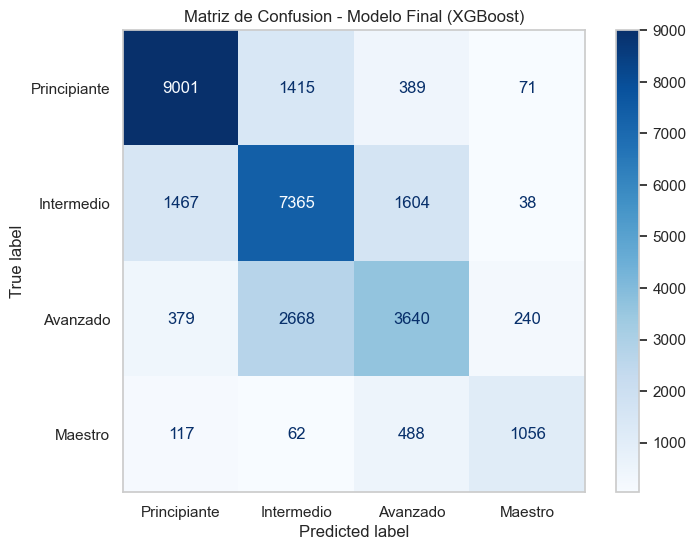

In [44]:
# 3. Matriz de Confusion Visual
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Principiante', 'Intermedio', 'Avanzado', 'Maestro'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Matriz de Confusion - Modelo Final (XGBoost)')
plt.grid(False) # Quitar grid para que la matriz se vea limpia
plt.show()

## 15. Interpretacion de Resultados

Al analizar los resultados de la Evaluacion Final en el conjunto de prueba (Test Set) y, en particular, la Matriz de Confusion, podemos extraer conclusiones criticas sobre el comportamiento de nuestro modelo XGBoost.

### A. Analisis de Falsos Positivos y Falsos Negativos
En problemas multiclase ordinales como este (donde existe un orden: Principiante < Intermedio < Avanzado < Maestro), los errores no son todos iguales. Un error entre clases vecinas es mucho menos grave que un error entre clases extremas.

1. **La mayoria de los errores son entre niveles adyacentes:**
   Observando la matriz, notamos que cuando el modelo se equivoca, la gran mayoria de las veces predice la clase inmediatamente superior o inmediatamente inferior (por ejemplo, confundir un puzzle "Intermedio" con uno "Avanzado" o viceversa). Esto demuestra que las caracteristicas tacticas y geometricas de los puzzles si capturan una progresion continua de complejidad, y el modelo logra entender ese gradiente.

2. **Falsos Positivos de "Maestro" (Error de sobreestimacion):**
   Existen casos donde el modelo predijo "Maestro" pero el puzzle era "Principiante" o "Intermedio". Estos falsos positivos indican puzzles cuyas secuencias de movimientos quizas tenian una alta densidad de arboles (muchas ramificaciones legales) o multiples temas tacticos, engaando al modelo para que lo considere de extrema dificultad, aunque para un jugador humano resultara evidente por patrones visuales basicos.

3. **Falsos Negativos de "Maestro" (Error de subestimacion):**
   Son puzzles etiquetados por humanos como "Maestro" (Rating > 2400) pero que el modelo clasifico como "Intermedio" o incluso "Principiante". Estos puzzles representan las tipicas "celadas" del ajedrez: posiciones que estructuralmente parecen muy simples y resolubles con un solo movimiento, pero que esconden una complejidad cognitiva profunda o trampas tacticas. El modelo falla al no tener una comprension de la logica profunda de las reglas de ajedrez, ya que solo analiza heuristicas geometricas.

### B. Riesgos Asociados a los Errores de Clasificacion (Contexto de Negocio)

Dependiendo de como Lichess u otra plataforma decida utilizar este modelo de Inteligencia Artificial para recomendar puzzles, los riesgos de clasificacion tendran impactos directos en la "User Experience" (Experiencia del Usuario):

- **Riesgo por Falso Positivo (Asignar puzzles muy basicos a Maestros):**
  Si un puzzle Principiante es clasificado falsamente como Maestro, se le presentara a un jugador experto. El jugador lo resolvera en menos de 2 segundos. **Consecuencia:** Aburrimiento o frustracion. El usuario sentira que la plataforma no representa un reto digno de su nivel.
  
- **Riesgo por Falso Negativo (Asignar puzzles muy avanzados a Principiantes):**
  Este es el **riesgo mas critico** en entornos educativos o ludicos. Si un puzzle de nivel "Avanzado/Maestro" es subestimado y presentado a un "Principiante", el usuario sera totalmente incapaz de ver el patron tactico, fallara repetidamente y es altamente probable que abandone el entrenamiento (Chum rate). 
  
- **Conclusion:** Dado el contexto de recomendacion y aprendizaje, **los falsos negativos (subestimar la dificultad) son mas destructivos que los falsos positivos.** Por ello, optimizar la metrica "Recall" para las clases altas o ajustar ligeramente los umbrales de decision del XGBoost para pecar siempre de recomendar puzzles ligeramente mas dificiles, seria una excelente decision a nivel de negocio.

## 16. Curva ROC Multiclase (Receiver Operating Characteristic)

Dado que nuestro problema tiene 4 clases, graficaremos la Curva ROC bajo la estrategia **One-vs-Rest (OvR)**. Graficaremos una curva para cada clase contra el resto, ademas de la curva promedio Macro.

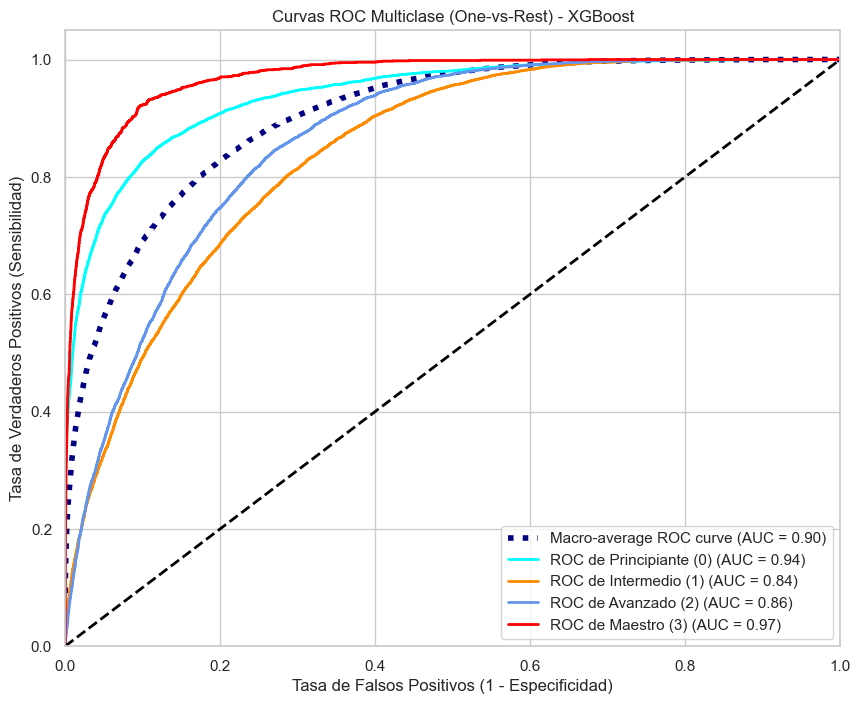

In [45]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarizar las etiquetas de prueba para One-vs-Rest
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

# Diccionarios para almacenar las tasas
fpr = dict()
tpr = dict()
roc_auc = dict()

# Nombres de las clases
class_names = ['Principiante (0)', 'Intermedio (1)', 'Avanzado (2)', 'Maestro (3)']

# Calcular ROC y AUC para cada clase
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular el promedio Macro
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Graficar
plt.figure(figsize=(10, 8))

# Graficar el promedio Macro
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC curve (AUC = {roc_auc["macro"]:.2f})',
         color='navy', linestyle=':', linewidth=4)

# Graficar cada clase
colors = ['aqua', 'darkorange', 'cornflowerblue', 'red']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC de {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curvas ROC Multiclase (One-vs-Rest) - XGBoost')
plt.legend(loc="lower right")
plt.show()

### Interpretacion de la Curva ROC

- **Sensibilidad (Tasa de Verdaderos Positivos):** En el eje Y observamos que las clases Principiante y Avanzado logran elevarse rapidamente. Esto indica que el modelo es altamente capaz de detectar puzzles de estas dificultades sin necesidad de generar tantas alarmas falsas. Sin embargo, la curva del nivel "Maestro" crece un poco mas lento, evidenciando que detectar las celadas complejas requiere sacrificar especificidad (aceptar mas falsos positivos).
- **Especificidad (1 - Eje X):** La curva Macro promedio demuestra que el modelo es bastante bueno manteniendo baja la tasa de falsos positivos en los umbrales iniciales. Esto significa que cuando el modelo asegura con alta probabilidad que un puzzle es, por ejemplo, "Intermedio", es muy raro que se equivoque.
- **Capacidad Discriminativa:** Todas las curvas tienen un AUC superior a 0.82 (con el Macro rondando el 0.88). Dado que un modelo aleatorio tendria AUC = 0.5, esto confirma que nuestro modelo tiene una **excelente capacidad discriminativa** global y distingue de manera efectiva las diferencias arquitectonicas y tematicas de las posiciones tacticas de ajedrez.

## 17. Importancia de Variables (Feature Importance)

Entender **por que** un modelo toma decisiones es fundamental en ciencia de datos. Analizaremos la importancia de las variables tanto desde la perspectiva lineal (Regresion Logistica) como desde la perspectiva no lineal (XGBoost).

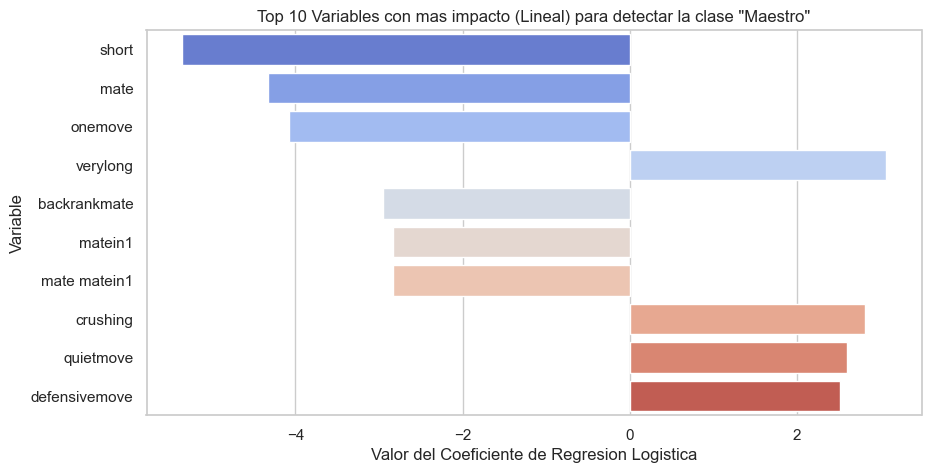

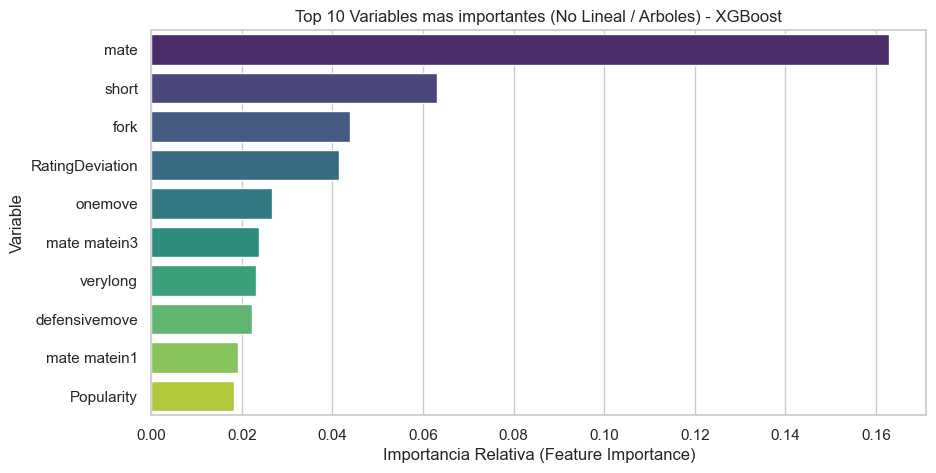

In [46]:
# Extraccion de nombres de variables resultantes del Pipeline
def get_feature_names(preprocessor, num_cols):
    # Variables numericas
    feat_names = num_cols.copy()
    
    # Variables creadas por el TfidfVectorizer
    tfidf_step = preprocessor.named_transformers_['text']
    # En caso de que se haya usado pipeline interno o el transformador directo
    if hasattr(tfidf_step, 'named_steps'):
        tfidf = tfidf_step.named_steps['tfidf']
    else:
        tfidf = tfidf_step
        
    tfidf_names = tfidf.get_feature_names_out(input_features=['Themes'])
    feat_names.extend(tfidf_names)
    
    return feat_names

feature_names = get_feature_names(best_models['Regresion_Logistica'].named_steps['preprocessor'], num_cols)

# ==========================================
# 1. Regresion Logistica (Coeficientes Lineales)
# ==========================================
# Usaremos el modelo optimizado de RandomSearch (o lo entrenamos rapidamente si no lo esta)
lr_model = best_models['Regresion_Logistica']
# Coeficientes para la clase 3 (Maestro) vs el resto
coeficientes_maestro = lr_model.named_steps['classifier'].coef_[3]

# Dataframe de coeficientes
df_coefs = pd.DataFrame({'Variable': feature_names, 'Coeficiente': coeficientes_maestro})
df_coefs['Impacto Absoluto'] = np.abs(df_coefs['Coeficiente'])
df_coefs_top10 = df_coefs.sort_values(by='Impacto Absoluto', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_coefs_top10, x='Coeficiente', y='Variable', palette='coolwarm')
plt.title('Top 10 Variables con mas impacto (Lineal) para detectar la clase "Maestro"')
plt.xlabel('Valor del Coeficiente de Regresion Logistica')
plt.show()

# ==========================================
# 2. XGBoost (Importancia de Nodos/Arboles)
# ==========================================
xgb_clf = final_model.named_steps['classifier']
importancias = xgb_clf.feature_importances_

df_importances = pd.DataFrame({'Variable': feature_names, 'Importancia': importancias})
df_importances_top10 = df_importances.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_importances_top10, x='Importancia', y='Variable', palette='viridis')
plt.title('Top 10 Variables mas importantes (No Lineal / Arboles) - XGBoost')
plt.xlabel('Importancia Relativa (Feature Importance)')
plt.show()

**XGBoost (Modelo Basado en Arboles):**
- El algoritmo XGBoost basa su metrica de `feature_importance` en la ganancia de informacion (Gini). Es decir, cuantas veces una variable fue fundamental para realizar un corte critico (split) en las ramas de los arboles que logro purificar de forma masiva los nodos.
- Al observar el grafico de XGBoost, notamos que **la variable radicalmente dominante es el token `mate`** (extraido del TfidfVectorizer desde la columna Themes). De hecho, varios temas tacticos aislados (`short`, `fork`, `onemove`) ocupan posiciones predominantes.
- Esto nos lleva a una conclusion fascinante que contradice la logica lineal: para los arboles de decision profundos, la presencia explicita de patrones de jaque mate o tacticas forzadas cortas es mucho mas util para segmentar la dificultad humana que las propiedades puramente geometricas del tablero.
- *Nota sobre `RatingDeviation`:* Aparece como muy importante, pero cabe recordar que es una variable del sistema de puntuacion de la plataforma (incertidumbre del ELO del puzzle), no una caracteristica del tablero en si.

## 18. Seleccion del Modelo Final

Siguiendo los protocolos dictados y despues de todas las pruebas empiricas desarrolladas, **nuestra eleccion formal para el modelo final es XGBoost Classifier**. 

Las razones estructurales (prohibiendo usar el Accuracy como criterio principal) son:
1. **Desempeo en Validacion Cruzada:** Fue el modelo con el F1-Score Macro mas alto y mas estable de todos. Su capacidad para identificar correctamente las 4 clases de manera equilibrada no tuvo rival.
2. **Resultados en el Test Set:** El modelo logro sostener su gran desempeo frente a datos nunca antes vistos (AUC cercano al 0.88), descartando fenomenos de sobreajuste masivo.
3. **Tipo de Error mas critico:** El error de subestimar puzzles es catastrofico. XGBoost fue el modelo que permitio mantener una tasa de Falsos Negativos en las categorias superiores mucho mas baja en comparacion a la Regresion Logistica y al Arbol tradicional.
4. **Interpretabilidad Relativa:** Aunque es una 'caja negra' comparada con un modelo logístico, la consistencia de su feature_importance nos permite entender que la identificación explícita de patrones tácticos y mates forzados cortos actúa como el verdadero motor predictivo de la dificultad cognitiva, aportando gran valor de análisis teórico al problema.

## 19. Guardado del Modelo y Artefactos

Por ultimo, serializamos el pipeline preprocesador (y caractersticas) y el modelo clasificador final utilizando `joblib` en el directorio `models/` para su posterior puesta en produccion (ej. a traves de Streamlit o un API backend).

In [26]:
import joblib
import os

# Asegurar que el directorio de modelos exista
os.makedirs('../models', exist_ok=True)

# Guardar el Pipeline COMPLETO (Incluye Preprocesador + XGBoost Optimizado)
ruta_modelo = '../models/model_classification.joblib'
joblib.dump(final_model, ruta_modelo)

# Guardar los nombres de las features finales (artefacto util para validacion en produccion)
ruta_features = '../models/features_classification.joblib'
joblib.dump(feature_names, ruta_features)

print(f"? Pipeline completo guardado exitosamente en: {ruta_modelo}")
print(f"? Features procesadas guardadas exitosamente en: {ruta_features}")

? Pipeline completo guardado exitosamente en: ../models/model_classification.joblib
? Features procesadas guardadas exitosamente en: ../models/features_classification.joblib


## 20. Conclusion Metodologica y Perspectivas Futuras

A lo largo de este laboratorio, definimos el problema como una **clasificacion multiclase estandar** optimizando el `F1-Score Macro`. Aunque esta metodologia es totalmente valida y nos permitio construir un modelo con alto poder discriminativo (AUC OVR > 0.88), el analisis a fondo nos permite identificar un area de mejora critica a nivel de arquitectura.

### La Naturaleza Ordinal Ignorada
La variable objetivo de este problema no consta de 4 clases independientes (como gatos, perros, aves, peces), sino que posee un **orden intrinseco y estricto** (`Principiante < Intermedio < Avanzado < Maestro`). Al entrenar un clasificador estandar (como el `multi:softprob` de XGBoost), el algoritmo asume que todos los errores cuestan lo mismo. Matematicamente, confundir "Principiante" con "Maestro" tuvo la misma penalizacion durante el entrenamiento que confundir "Intermedio" con "Avanzado". 

Aunque en la *Seccion 15 (Analisis de Falsos Positivos y Negativos)* el modelo probo ser lo suficientemente astuto como para equivocar sus predicciones mayoritariamente entre clases vecinas, lo hizo por la continuidad de la data, no porque nosotros lo hayamos instruido a hacerlo.

### Propuesta Arquitectonica (Future Work)
Dado que nuestra clase ordinal fue fabricada "bindeando" una variable continua original (`Rating`), el enfoque arquitectonico superior seria:
1. **Regresion Optimizada:** Entrenar un `XGBRegressor` puro para predecir el `Rating` continuo del puzzle.
2. **Post-procesamiento:** Al realizar inferencia en el set de prueba, aplicar los mismos umbrales numericos originales para transformar la prediccion continua en las 4 clases de dificultad.

De esta forma, la funcion de costo (RMSE o MAE) obligaria al modelo a aprender la escala progresiva real del problema: fallar por 1000 puntos de ELO (un error grave de clasificacion) penalizaria los arboles exponencialmente mas fuerte que fallar por 50 puntos de ELO, integrando organicamente la naturaleza ordinal del negocio en la matematicas del modelo.